## 1. Загрузка данных и первичный анализ

Первые 5 строк датасета:


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


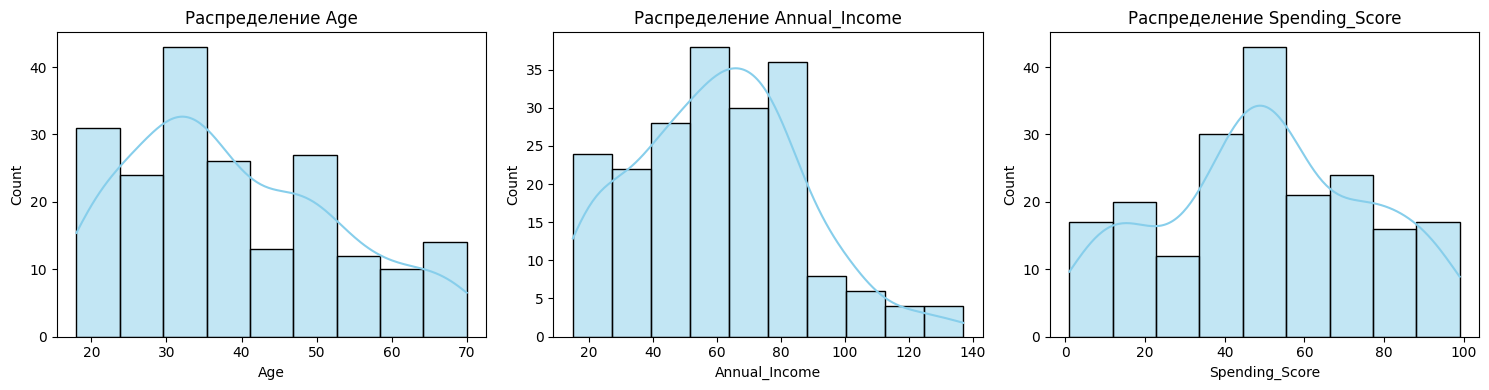

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка датасета по прямой ссылке
url = "https://raw.githubusercontent.com/ivtipm/ML/main/datasets/Mall_Customers.csv"
df = pd.read_csv(url)

# Переименуем колонки для удобства работы
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о типах данных и пропусках:")
print(df.info())

# Визуализация распределений признаков
plt.figure(figsize=(15, 4))
for i, col in enumerate(['Age', 'Annual_Income', 'Spending_Score']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

## 2. Подготовка и стандартизация данных

#### Ответ на вопрос задания: Нужно ли стандартизовать данные?
Да, обязательно. Алгоритмы кластеризации (K-Means, DBSCAN, агломеративная кластеризация) основаны на подсчете расстояний (евклидовой метрики) между объектами. Так как масштаб дохода (до 137k) и возраста (до 70 лет) существенно различается, без стандартизации признак с большим масштабом будет оказывать доминирующее влияние на группировку.

In [2]:
from sklearn.preprocessing import StandardScaler

# Отбираем признаки для кластеризации (игнорируем CustomerID и, например, Gender для простоты)
X = df[['Age', 'Annual_Income', 'Spending_Score']]

# Также популярно кластеризовать только по двум признакам для наглядной 2D-визуализации:
# X_2d = df[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Метод K-Means

#### Для K-Means ключевой параметр — количество кластеров K. Мы найдем оптимальное число кластеров с помощью метода локтя (Elbow Method) и коэффициента силуэта (Silhouette Score)

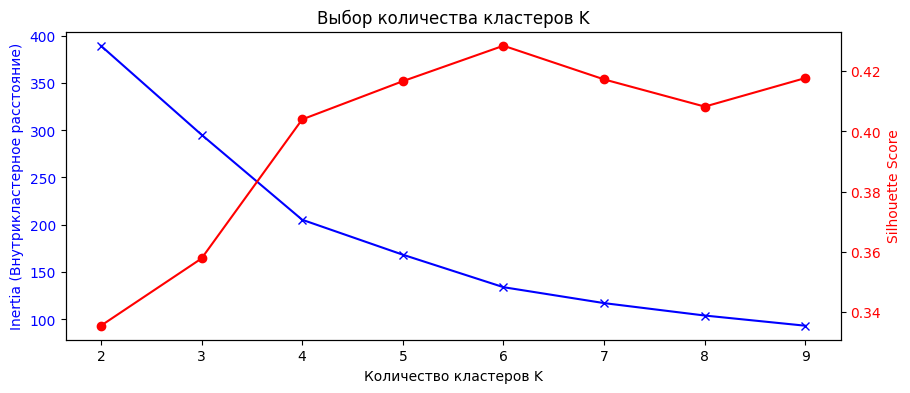

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Строим графики для выбора K
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(K_range, inertia, 'bx-', label='Inertia (Метод локтя)')
ax1.set_xlabel('Количество кластеров K')
ax1.set_ylabel('Inertia (Внутрикластерное расстояние)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Выбор количества кластеров K')
plt.show()

## 4. Сравнение нескольких алгоритмов (K-Means И DBSCAN)

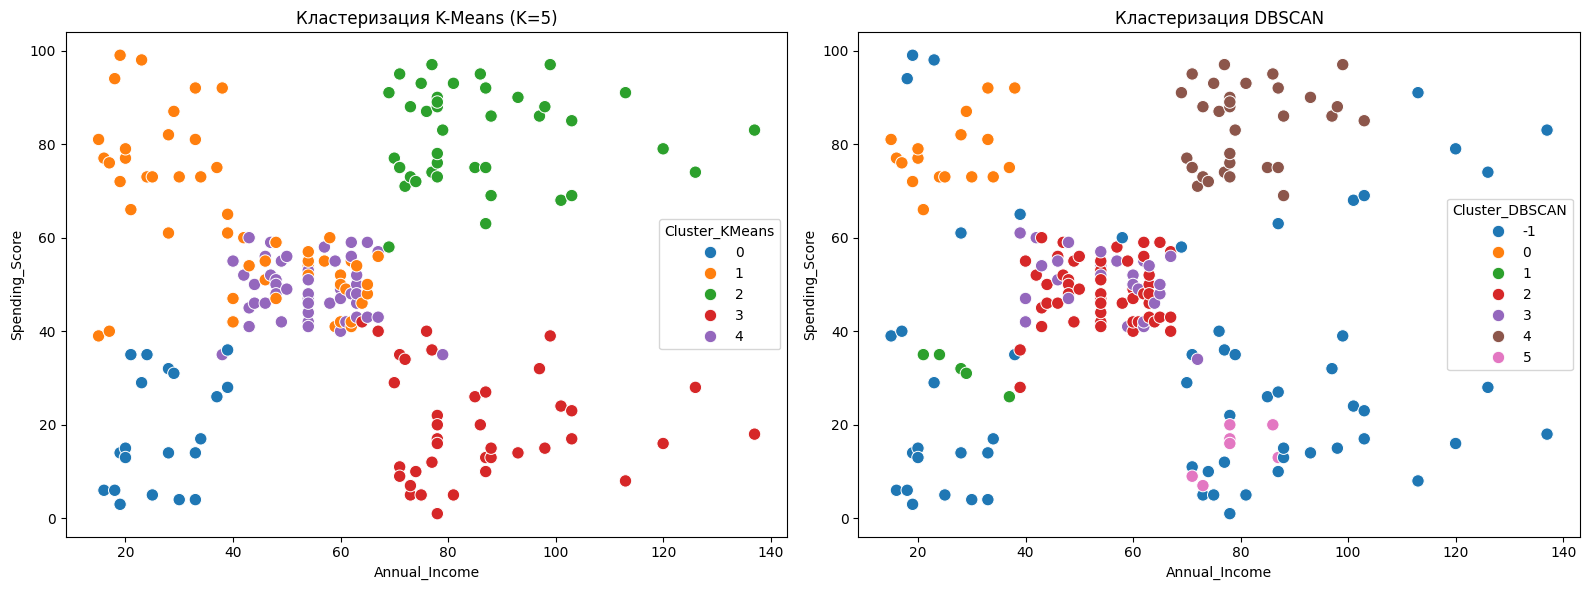

In [4]:
from sklearn.cluster import DBSCAN

# 1. K-Means
kmeans_best = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_best.fit_predict(X_scaled)

# 2. DBSCAN
# eps и min_samples подбираются экспериментально. eps регулирует радиус окрестности.
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Визуализация результатов двух алгоритмов на плоскости Доход vs Расходы
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График KMeans
sns.scatterplot(
    data=df, x='Annual_Income', y='Spending_Score', 
    hue='Cluster_KMeans', palette='tab10', ax=axes[0], s=80
)
axes[0].set_title('Кластеризация K-Means (K=5)')

# График DBSCAN (-1 означает шум/выбросы)
sns.scatterplot(
    data=df, x='Annual_Income', y='Spending_Score', 
    hue='Cluster_DBSCAN', palette='tab10', ax=axes[1], s=80
)
axes[1].set_title('Кластеризация DBSCAN')

plt.tight_layout()
plt.show()

## 5. Анализ и сравнение групп клиентов (Профилирование)

Профили кластеров (средние значения признаков):


,Age,Annual_Income,Spending_Score
Cluster_KMeans,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


C:\Users\asizi\AppData\Local\Temp\ipykernel_34576\3041672924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_KMeans', y=col, ax=axes[i], palette='tab10')
C:\Users\asizi\AppData\Local\Temp\ipykernel_34576\3041672924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_KMeans', y=col, ax=axes[i], palette='tab10')
C:\Users\asizi\AppData\Local\Temp\ipykernel_34576\3041672924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_KMeans', y=col, ax=axes[i], palette='tab10')


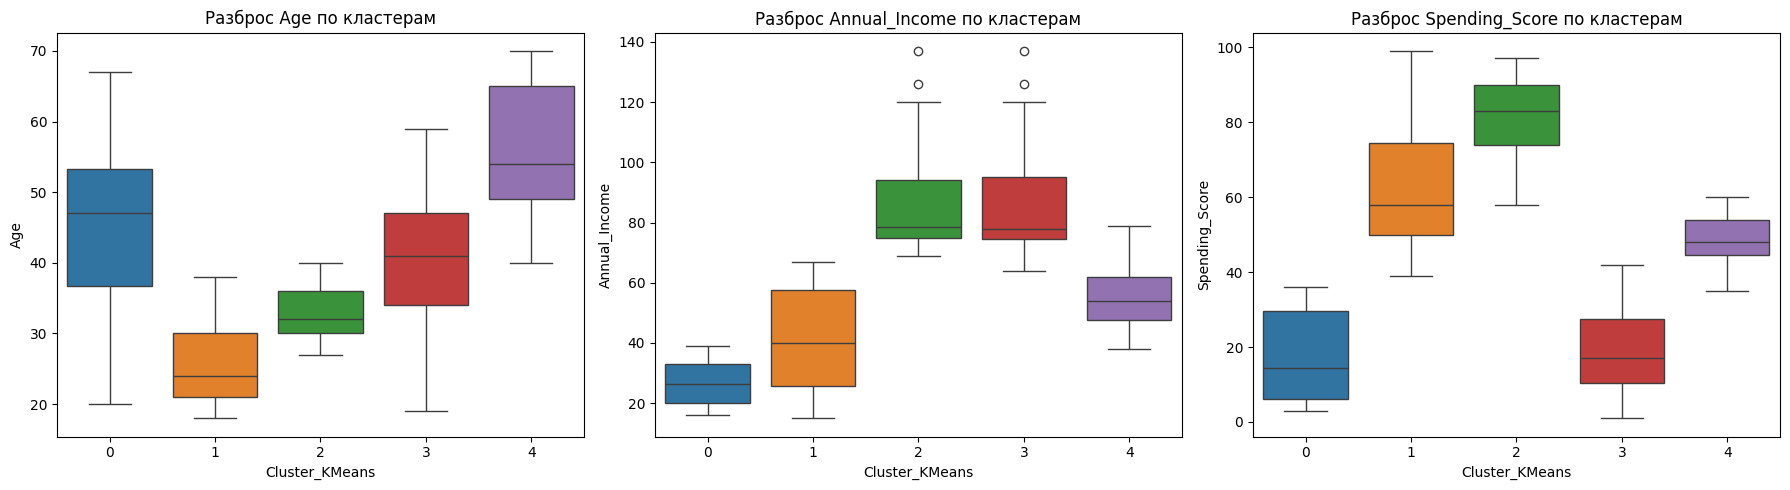

In [5]:
# Группируем данные и смотрим на средние значения признаков в каждом кластере
cluster_profile = df.groupby('Cluster_KMeans')[['Age', 'Annual_Income', 'Spending_Score']].mean()
print("Профили кластеров (средние значения признаков):")
display(cluster_profile)

# Построим боксплоты для визуализации различий между кластерами
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Age', 'Annual_Income', 'Spending_Score']):
    sns.boxplot(data=df, x='Cluster_KMeans', y=col, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Разброс {col} по кластерам')
plt.tight_layout()
plt.show()

## 6. Ответы на поставленные вопросы

1. **Какие параметры каких алгоритмов влияют на результат?**
   * В **K-Means** критически важно количество кластеров `n_clusters`. Неверный выбор $K$ приведет к объединению разных групп или искусственному дроблению естественных скоплений.
   * В **DBSCAN** ключевые параметры — `eps` (максимальное расстояние между точками для объединения в один кластер) и `min_samples` (минимальное число точек в окрестности для формирования ядра). При слишком малом `eps` всё превратится в шум, а при слишком большом — сольется в один гигантский кластер.
2. **Как влияет на результат выбор нормы (метрики расстояния)?**
   * По умолчанию используется *Евклидово расстояние* ($L_2$-норма), которое хорошо работает для сферических плотных кластеров.
   * Использование *Манхэттенского расстояния* ($L_1$-норма) делает алгоритм менее чувствительным к редким выбросам (клиентам с аномально высоким доходом), так как оно не возводит разности в квадрат.
3. **Насколько элементы разрежены в пространстве признаков?**
   * Плотность данных неоднородна. В центре (средний возраст, средний доход ~50k, средние расходы ~50) данные расположены очень плотно. В то же время по углам (высокий доход / низкие расходы и высокий доход / высокие расходы) данные формируют изолированные, но разреженные по своей структуре группы. По результатам DBSCAN это будет хорошо заметно: точки на периферии часто помечаются как шум (класс `-1`).